# Titanic Dataset Analysis — Assignment 2
## Feature Engineering & Selection Notebook

This notebook walks through the full pipeline:
1. **Part 1** – Data Cleaning
2. **Part 2** – Feature Engineering
3. **Part 3** – Feature Selection

The modular scripts in `scripts/` implement the same logic and can be run independently.

## 0 – Setup

In [1]:
import sys, os
# Make scripts importable regardless of working directory
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
ASSIGN_DIR   = os.path.join(NOTEBOOK_DIR, "..")
sys.path.insert(0, os.path.join(ASSIGN_DIR, "scripts"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_cleaning import load_data, clean
from feature_engineering import engineer
from feature_selection import select

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

DATA_DIR = os.path.join(ASSIGN_DIR, "data")
RAW_PATH = os.path.join(DATA_DIR, "train.csv")
CLEAN_PATH = os.path.join(DATA_DIR, "train_cleaned.csv")
ENG_PATH   = os.path.join(DATA_DIR, "train_engineered.csv")
SEL_PATH   = os.path.join(DATA_DIR, "train_selected.csv")

---
## Part 1 – Data Cleaning

### Decision Log

| Column | Issue | Decision |
|---|---|---|
| Age | ~20 % missing | Add `HasAge` indicator, impute with **median** |
| Embarked | 2 missing | Impute with **mode** (S) |
| Fare | rarely missing | Impute with **median** |
| Cabin | ~77 % missing | Extract first letter as `Deck`; remainder → "Unknown"; drop raw column |
| Sex | potential casing | Standardise to lowercase |
| Duplicates | — | Drop exact duplicate rows |

**Outlier strategy:** IQR capping (3×IQR for Fare — genuinely skewed; 1.5×IQR for Age).

In [2]:
df_raw = load_data(RAW_PATH)
print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# ── Missing values before cleaning ──
missing = df_raw.isnull().sum()
print("Missing values:\n", missing[missing > 0])

Missing values:
 Age         177
Cabin       687
Embarked      2
dtype: int64


In [4]:
# ── Run cleaning pipeline ──
df_clean = clean(df_raw)
df_clean.to_csv(CLEAN_PATH, index=False)
print(f"Clean shape: {df_clean.shape}")
df_clean.isnull().sum()

[data_cleaning] Handling missing values …
[data_cleaning] Handling outliers …
[data_cleaning] Fixing consistency issues …
Clean shape: (891, 13)


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasAge         0
Deck           0
dtype: int64

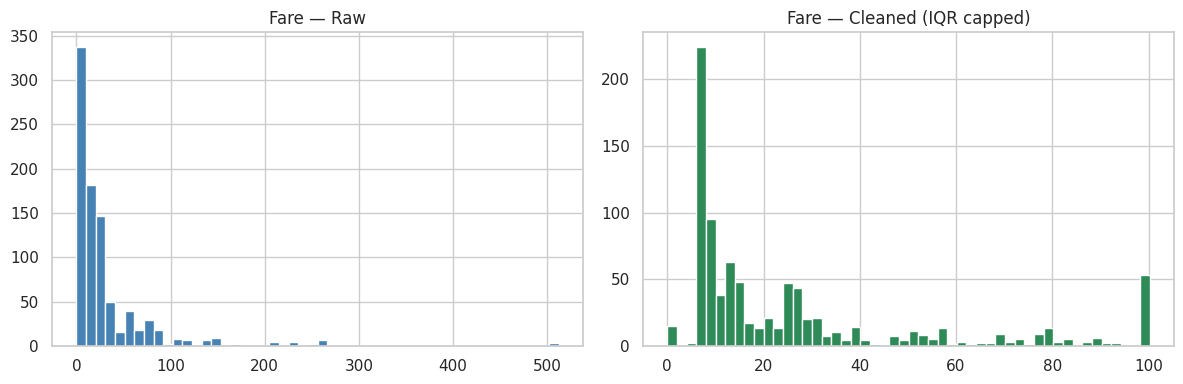

In [5]:
# ── Fare distribution (before and after capping) ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_raw["Fare"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Fare — Raw")
axes[1].hist(df_clean["Fare"], bins=50, color="seagreen", edgecolor="white")
axes[1].set_title("Fare — Cleaned (IQR capped)")
plt.tight_layout()
plt.show()

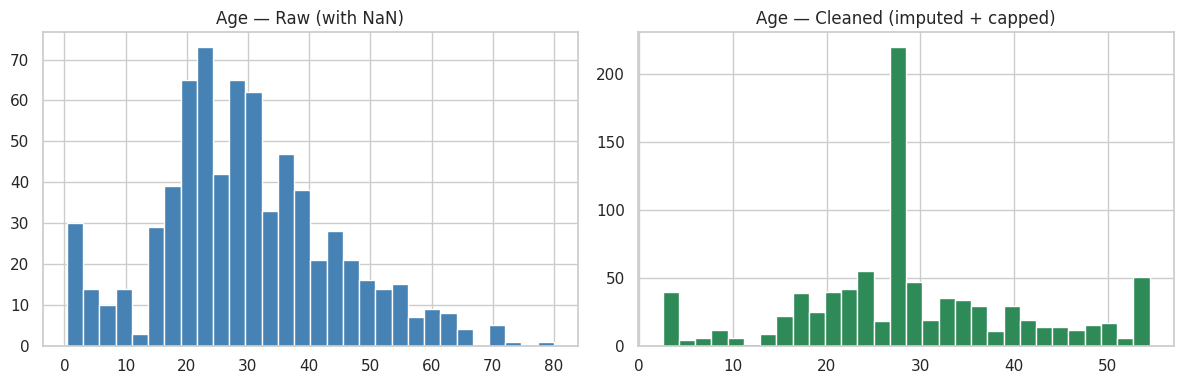

In [6]:
# ── Age distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_raw["Age"].dropna(), bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Age — Raw (with NaN)")
axes[1].hist(df_clean["Age"], bins=30, color="seagreen", edgecolor="white")
axes[1].set_title("Age — Cleaned (imputed + capped)")
plt.tight_layout()
plt.show()

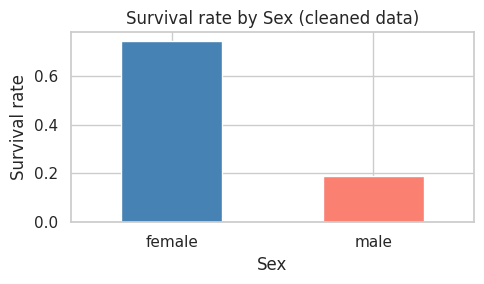

In [7]:
# ── Survival rate by Sex (sanity check) ──
df_clean.groupby("Sex")["Survived"].mean().plot.bar(
    color=["steelblue", "salmon"], edgecolor="white", figsize=(5, 3)
)
plt.title("Survival rate by Sex (cleaned data)")
plt.ylabel("Survival rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Part 2 – Feature Engineering

New features created:

| Feature | Formula / Logic |
|---|---|
| FamilySize | SibSp + Parch + 1 |
| IsAlone | 1 if FamilySize == 1 |
| Title | Regex extraction from Name; rare → "Rare" |
| AgeGroup | Bins: Child / Teen / Adult / Senior |
| FarePerPerson | Fare / FamilySize |
| LogFare | log1p(Fare) |
| LogAge | log1p(Age) |
| Pclass_x_Fare | Interaction: Pclass × Fare |
| Age_x_IsAlone | Interaction: Age × IsAlone |

Categorical columns one-hot encoded: Sex, Embarked, Title, Deck, AgeGroup.

In [8]:
df_eng = engineer(df_clean)
df_eng.to_csv(ENG_PATH, index=False)
print(f"Engineered shape: {df_eng.shape}")
df_eng.head()

[feature_engineering] Adding family features …
[feature_engineering] Extracting titles …
[feature_engineering] Adding age groups …
[feature_engineering] Adding fare-per-person …
[feature_engineering] Adding log transforms …
[feature_engineering] Adding interaction features …
[feature_engineering] Encoding categorical features …
Engineered shape: (891, 38)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,HasAge,FamilySize,IsAlone,FarePerPerson,LogFare,LogAge,Pclass_x_Fare,Age_x_IsAlone,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown,AgeGroup_Child,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_Senior
0,1,0,3,22.0,1,0,7.2500,1,2,0,3.62500,2.110213,3.135494,21.7500,0.0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
1,2,1,1,38.0,1,0,71.2833,1,2,0,35.64165,4.280593,3.663562,71.2833,0.0,1,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0
2,3,1,3,26.0,0,0,7.9250,1,1,1,7.92500,2.188856,3.295837,23.7750,26.0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
3,4,1,1,35.0,1,0,53.1000,1,2,0,26.55000,3.990834,3.583519,53.1000,0.0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0
4,5,0,3,35.0,0,0,8.0500,1,1,1,8.05000,2.202765,3.583519,24.1500,35.0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0


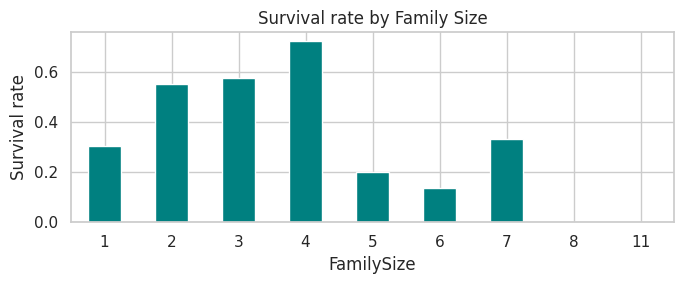

In [9]:
# ── FamilySize distribution ──
df_clean_temp = df_clean.copy()
df_clean_temp["FamilySize"] = df_clean_temp["SibSp"] + df_clean_temp["Parch"] + 1
survival_by_family = df_clean_temp.groupby("FamilySize")["Survived"].mean()
survival_by_family.plot.bar(color="teal", edgecolor="white", figsize=(7, 3))
plt.title("Survival rate by Family Size")
plt.ylabel("Survival rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

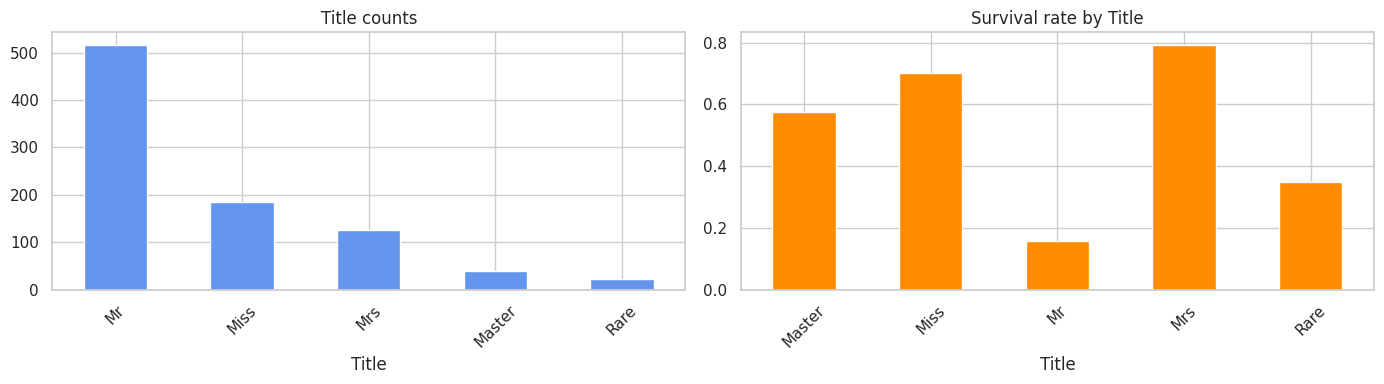

In [10]:
# ── Title counts ──
from feature_engineering import add_title
df_titled = add_title(df_clean)
title_counts = df_titled["Title"].value_counts()
title_survival = df_titled.groupby("Title")["Survived"].mean()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
title_counts.plot.bar(ax=axes[0], color="cornflowerblue", edgecolor="white")
axes[0].set_title("Title counts")
axes[0].tick_params(axis='x', rotation=45)
title_survival.plot.bar(ax=axes[1], color="darkorange", edgecolor="white")
axes[1].set_title("Survival rate by Title")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

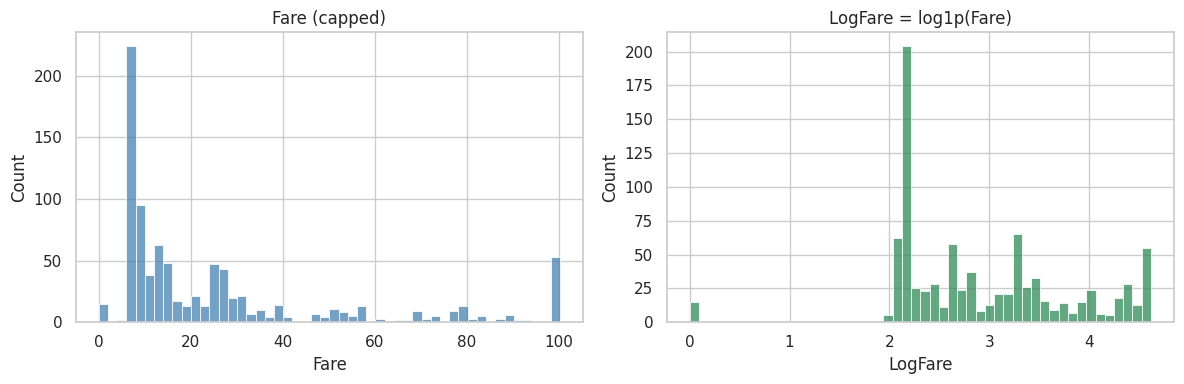

In [11]:
# ── Log-transform justification ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_eng["Fare"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Fare (capped)")
sns.histplot(df_eng["LogFare"], bins=50, ax=axes[1], color="seagreen")
axes[1].set_title("LogFare = log1p(Fare)")
plt.tight_layout()
plt.show()

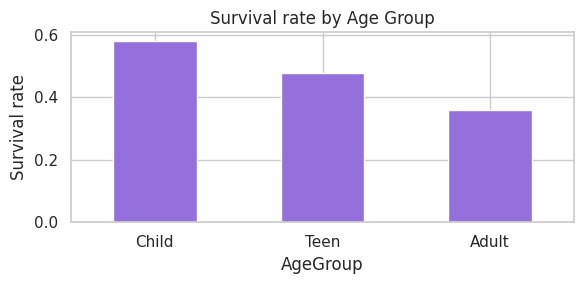

In [12]:
# ── AgeGroup survival ──
from feature_engineering import add_age_group, add_family_features
df_age = add_age_group(add_family_features(df_clean))
df_age.groupby("AgeGroup", observed=True)["Survived"].mean().plot.bar(
    color="mediumpurple", edgecolor="white", figsize=(6, 3)
)
plt.title("Survival rate by Age Group")
plt.ylabel("Survival rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Part 3 – Feature Selection

Three-step approach:
1. **Correlation analysis** – remove redundant features (|r| > 0.90).
2. **Random Forest importance** – rank remaining features.
3. **RFE** (Logistic Regression, extra credit) – select top 15 via recursive elimination.

Final feature set = union of RF-top-15 and RFE-selected.

In [13]:
df_sel, final_features = select(df_eng)
df_sel.to_csv(SEL_PATH, index=False)
print(f"\nSelected dataset shape: {df_sel.shape}")
print(f"Final features ({len(final_features)}):", final_features)

[feature_selection] Step 1 – Correlation analysis …
[feature_selection] Dropping 'Fare' (|r|=0.90 with 'LogFare')
[feature_selection] Dropping 'Age' (|r|=0.91 with 'LogAge')
[feature_selection] Dropping 'Sex_female' (|r|=1.00 with 'Sex_male')

[feature_selection] Step 2 – Random Forest feature importance …


/home/runner/.local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/runner/.local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



Top 20 features by Random Forest importance:
Title_Mr          0.113612
FarePerPerson     0.106700
Sex_male          0.103292
LogAge            0.100288
LogFare           0.095493
Pclass_x_Fare     0.089476
Age_x_IsAlone     0.062727
Pclass            0.044328
Title_Miss        0.039342
FamilySize        0.036100
Title_Mrs         0.035317
Deck_Unknown      0.026234
SibSp             0.024518
Parch             0.013916
HasAge            0.013387
Embarked_S        0.011542
Embarked_C        0.010245
AgeGroup_Child    0.007611
AgeGroup_Adult    0.007414
Title_Rare        0.006990

[feature_selection] Step 3 – RFE (Logistic Regression, top 15) …

RFE-selected features (15):
  • Pclass
  • SibSp
  • Parch
  • FamilySize
  • FarePerPerson
  • LogFare
  • LogAge
  • Pclass_x_Fare
  • Sex_male
  • Embarked_S
  • Title_Master
  • Title_Mrs
  • Deck_C
  • Deck_T
  • Deck_Unknown

[feature_selection] Final selected features (19):
  [RF][   ]  Age_x_IsAlone
  [  ][RFE]  Deck_C
  [  ][RFE]  Deck_

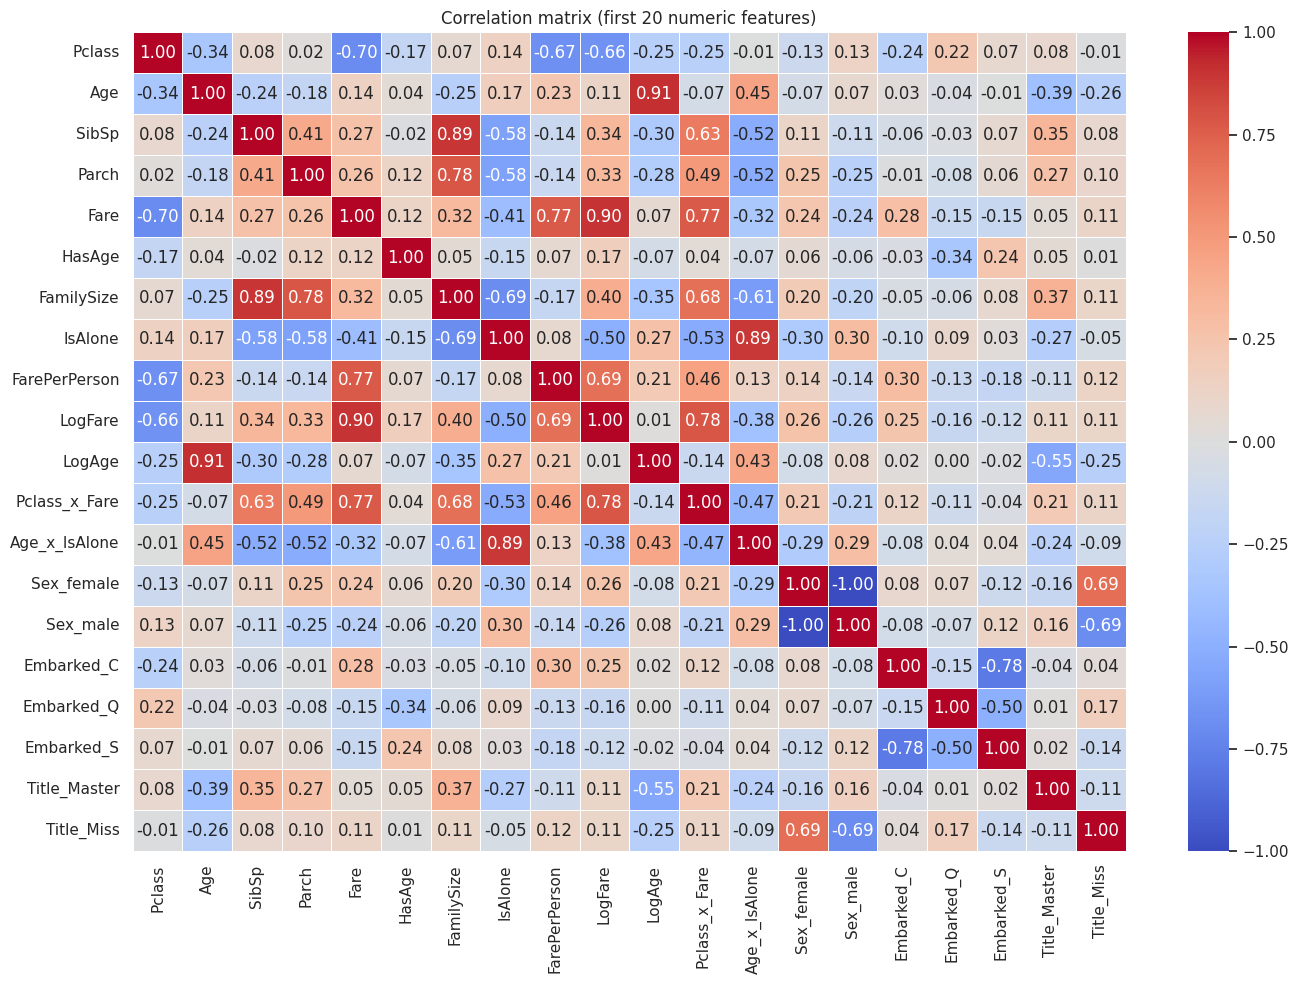

In [14]:
# ── Correlation heatmap (engineered feature subset) ──
numeric_cols = [c for c in df_eng.select_dtypes(include="number").columns
                if c not in ("PassengerId", "Survived")][:20]
corr = df_eng[numeric_cols].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation matrix (first 20 numeric features)")
plt.tight_layout()
plt.show()

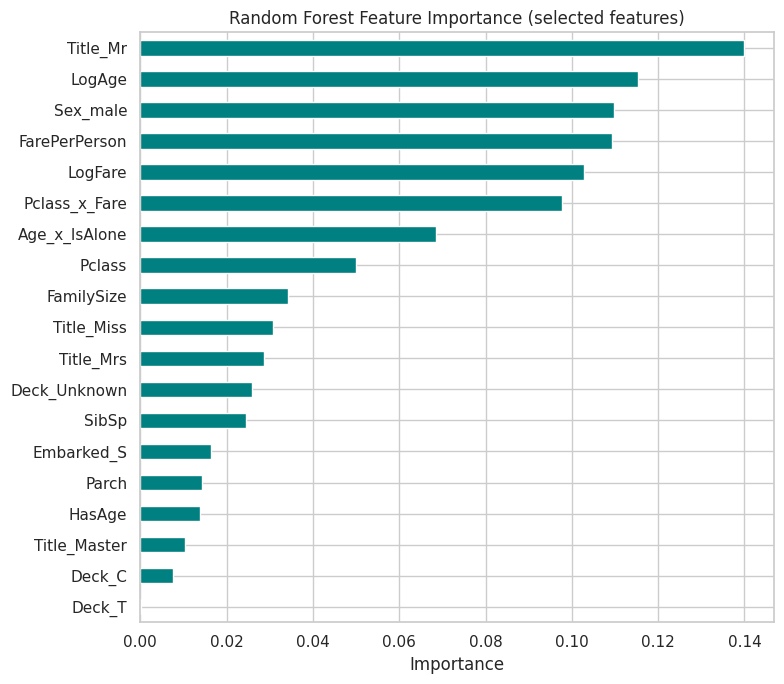

In [15]:
# ── Random Forest importance bar chart ──
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

TARGET = "Survived"
ID_COL = "PassengerId"
feature_cols = [c for c in df_sel.columns if c not in (ID_COL, TARGET)]
X = df_sel[feature_cols].fillna(0)
y = df_sel[TARGET]

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
importance.plot.barh(figsize=(8, 7), color="teal", edgecolor="white")
plt.title("Random Forest Feature Importance (selected features)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

---
## Summary

| Feature | Kept | Reason |
|---|---|---|
| Title_Mr / Mrs / Miss | ✅ | Highest RF importance; encodes sex + social role |
| FarePerPerson | ✅ | Better per-passenger economic signal than raw Fare |
| Sex_male | ✅ | Direct survival predictor (women-first policy) |
| LogAge / LogFare | ✅ | Reduced skew; preferred over raw Age/Fare |
| Pclass_x_Fare | ✅ | Captures interaction between class and wealth |
| Age_x_IsAlone | ✅ | Distinguishes lone children vs lone adults |
| Pclass | ✅ | Strong socioeconomic proxy |
| FamilySize / SibSp / Parch | ✅ | Group-travel dynamics |
| Deck features | ✅ | Partial ship-location signal |
| Sex_female | ❌ | Perfectly correlated with Sex_male (dropped) |
| Raw Fare / Age | ❌ | Superseded by log-transformed versions |
